## chapter 6

#### example 1

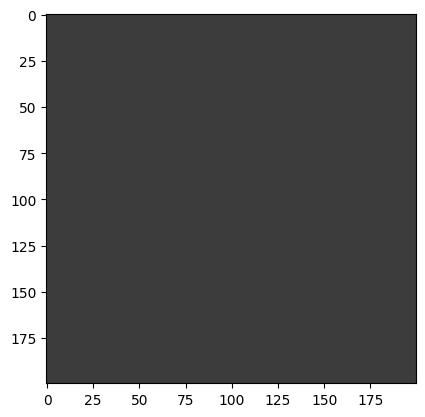

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

img = torch.full((200, 200, 3), 60)
plt.imshow(img)
plt.show()

#plt.imread()
#plt.imshow()
#plt.imsave()

#### example 2: CNN (convolutional neural network)

- application:
    + picture classification
    + picture separation: according to the meaning
    + facial recognization
- algorithm and structure:
    + convolution -> pooling -> full-connected
- padding: add extra pixels at the edge(usually 0)
    + valid padding: add nothing(when input is big enough or keeping size isn't required)
    + same padding: add pixels to get a same-size picture(when keeping size is required)
    + full padding: enlarge the size of feature picture(require more calculation)
- stride: length of step when convolutional core slides
    + reduce calculation and enlarge receptive field
- about multi-channel:
    - matrix multiple(3 single channel)-> add 3 channels -> 1 map
- feature picture size(N, side length):
    N = ((W(picture) - F(convolutional core size) + 2P(padding)) / S(stride)) + 1
- pooling:
    + maximize pooling(applied more) and mean pooling
    + won't change channel number

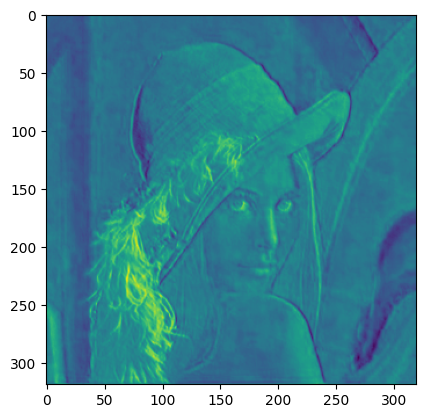

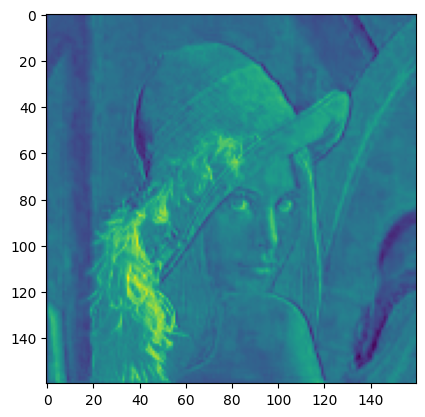

In [47]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np


img = plt.imread('D:\code\python\deep learning\day6\data\\img.jpg')
#print(img.shape) (640, 640, 3)
img = torch.tensor(img, dtype=torch.float)
img = img.permute(2, 0, 1)
img = torch.unsqueeze(img, dim=0)
#print(img.shape) [1, 3, 640, 640]
#create convolutional layer
conv = nn.Conv2d(in_channels=3, 
                 out_channels=4, #number of convolutional kernel(neuron) 
                 kernel_size=3, 
                 stride=2, 
                 padding=0)
conv_img = conv(img)

out_img = conv_img[0]
out_img = out_img.permute(1, 2, 0)
out_img = out_img[:, :, 2].detach().numpy()
plt.imshow(out_img)
plt.show()
#create pooling layer
#maximize pooling
pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=1)
#average pooling
pool = nn.AvgPool2d(kernel_size=2, stride=2, padding=1)
pool_img = pool(conv_img)

#print(conv_img.shape) [1, 4, 319, 319]
out_img = pool_img[0]
out_img = out_img.permute(1, 2, 0)
#print(out_img.shape) [319, 319, 4]
out_img = out_img[:, :, 2].detach().numpy()
plt.imshow(out_img)
plt.show()
